In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import inf

rng = np.random.default_rng(20250801)

# ---------------------------------------------------------------------
# Shared split helpers
# ---------------------------------------------------------------------
def _cum_stats(y):
    csum = np.cumsum(y)
    csum2 = np.cumsum(y**2)
    return csum, csum2

def _node_stats(csum, csum2, i, n):
    nL, nR = i, n - i
    meanL = csum[i-1] / nL
    meanR = (csum[-1] - csum[i-1]) / nR
    varL = max(0.0, csum2[i-1] / nL - meanL**2)
    varR = max(0.0, (csum2[-1] - csum2[i-1]) / nR - meanR**2)
    return nL, nR, meanL, meanR, varL, varR

def best_split_sorted(y_sorted, min_leaf=1, criterion='cart', alpha=None):
    """
    Given y sorted by x, return (split_index, score, min_child_prop).

    criterion in {'cart','minimax','C1','C2','covrt','alpha_cart'}.
    """
    n = len(y_sorted)
    csum, csum2 = _cum_stats(y_sorted)

    if criterion in ('C2', 'covrt'):
        best_score = -inf
    else:
        best_score = inf
    best_idx = None
    best_prop = None

    for i in range(min_leaf, n - min_leaf + 1):
        nL, nR, meanL, meanR, varL, varR = _node_stats(csum, csum2, i, n)
        prop = min(nL, nR) / n

        if criterion == 'alpha_cart' and alpha is not None and prop < alpha:
            continue

        if criterion == 'cart' or criterion == 'alpha_cart':
            score = nL * varL + nR * varR
            better = score < best_score
        elif criterion == 'minimax':
            score = max(nL * varL, nR * varR)
            better = score < best_score
        elif criterion == 'C1':
            score = min(varL, varR)
            better = score < best_score
        elif criterion == 'C2':
            score = max(meanL, meanR)
            better = score > best_score
        elif criterion == 'covrt':
            pL = nL / n
            pR = nR / n
            score = (pL**2) * (pR**2) * (meanL - meanR)**2
            better = score > best_score
        else:
            raise ValueError(f"unknown criterion: {criterion}")

        if better:
            best_score = score
            best_idx = i
            best_prop = prop

    return best_idx, best_score, best_prop

def random_split_unif(x, rng):
    n = len(x)
    cut = rng.uniform(x.min(), x.max())
    nL = np.searchsorted(x, cut, side='right')
    return min(nL, n - nL) / n

def random_split_obs(x, rng):
    n = len(x)
    cut = rng.choice(x)
    nL = np.searchsorted(x, cut, side='right')
    return min(nL, n - nL) / n

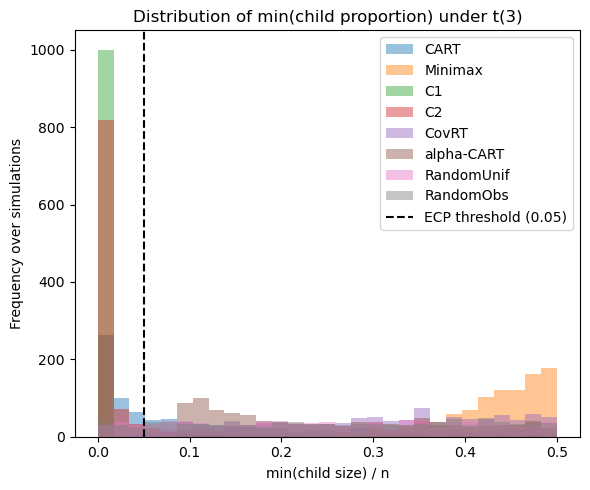

Mean min-child proportion:
CART      : 0.144  ECP%: 42.5%
Minimax   : 0.426  ECP%:  0.0%
C1        : 0.002  ECP%: 100.0%
C2        : 0.019  ECP%: 92.4%
CovRT     : 0.315  ECP%:  0.9%
alpha-CART: 0.254  ECP%:  0.0%
RandomUnif: 0.249  ECP%:  9.7%
RandomObs : 0.257  ECP%:  8.9%


In [12]:
# ---------------------------------------------------------------------
# Root-split ECP experiment: keep the original histogram style
# ---------------------------------------------------------------------
n_samples = 500
n_rep = 1000
edge_thr = 0.05
alpha_ecp = 0.10
df_t = 3

methods = {
    "CART":       lambda x, y: best_split_sorted(y, min_leaf=1, criterion='cart')[2],
    "Minimax":    lambda x, y: best_split_sorted(y, min_leaf=1, criterion='minimax')[2],
    "C1":         lambda x, y: best_split_sorted(y, min_leaf=1, criterion='C1')[2],
    "C2":         lambda x, y: best_split_sorted(y, min_leaf=1, criterion='C2')[2],
    "CovRT":      lambda x, y: best_split_sorted(y, min_leaf=1, criterion='covrt')[2],
    "alpha-CART": lambda x, y: best_split_sorted(y, min_leaf=1, criterion='alpha_cart', alpha=alpha_ecp)[2],
    "RandomUnif": lambda x, y: random_split_unif(x, rng),
    "RandomObs":  lambda x, y: random_split_obs(x, rng),
}

results = {k: [] for k in methods}

for _ in range(n_rep):
    x = rng.random(n_samples)
    y = rng.standard_t(df_t, size=n_samples)
    #y = rng.standard_normal(size=n_samples)
    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    for name, fn in methods.items():
        val = fn(x_sorted, y_sorted)
        if val is not None:
            results[name].append(val)

for k in results:
    results[k] = np.array(results[k])

plt.figure(figsize=(6, 5))
bins = np.linspace(0, 0.5, 30)
for name, vals in results.items():
    plt.hist(vals, bins=bins, alpha=0.45, label=name, density=False)
plt.axvline(edge_thr, color='k', linestyle='--', label=f"ECP threshold ({edge_thr})")
plt.title(f"Distribution of min(child proportion) under t({df_t})")
plt.xlabel("min(child size) / n")
plt.ylabel("Frequency over simulations")
plt.legend()
plt.tight_layout()
plt.show()

print("Mean min-child proportion:")
for name, vals in results.items():
    print(f"{name:10s}: {vals.mean():.3f}  ECP%: {(vals <= edge_thr).mean() * 100:4.1f}%")

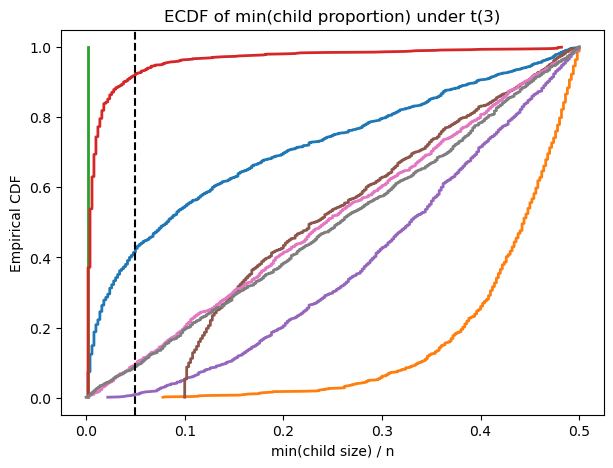

In [13]:
plt.figure(figsize=(7, 5))

for name, vals in results.items():
    xs = np.sort(vals)
    ys = np.arange(1, len(xs) + 1) / len(xs)
    plt.plot(xs, ys, linewidth=2, label=name)

plt.axvline(edge_thr, color='k', linestyle='--', linewidth=1.5,
            label=f"ECP threshold ({edge_thr})")
plt.title(f"ECDF of min(child proportion) under t({df_t})")
plt.xlabel("min(child size) / n")
plt.ylabel("Empirical CDF")
#plt.legend(loc="lower center", bbox_to_anchor=(1.02, 1.5), ncol=9, frameon=True)
#plt.tight_layout(rect=[0, 0, 0.72, 1])
#plt.tight_layout()
plt.show()

    Criterion  Avg leaf size mean  Avg leaf size variance  Avg depth  \
0        CART               5.106                   5.930      11.81   
1     Minimax               4.962                   1.194       8.77   
2          C1              15.316                2285.665      12.00   
3          C2               7.113                 159.215      12.00   
4       CovRT               4.956                   1.160      10.75   
5  alpha-CART               4.981                   1.940      11.65   

   Avg train MSE  Avg test MSE  
0          0.006         0.016  
1          0.008         0.015  
2          0.152         0.156  
3          0.012         0.019  
4          0.006         0.016  
5          0.006         0.016  
running: 0.0 0
running: 0.0 1
running: 0.0 2
running: 0.0 3
running: 0.0 4
running: 0.0 5
running: 0.0 6
running: 0.0 7
running: 0.0 8
running: 0.0 9
running: 0.0 10
running: 0.0 11
running: 0.0 12
running: 0.0 13
running: 0.0 14
running: 0.0 15
running: 0.01 0
ru

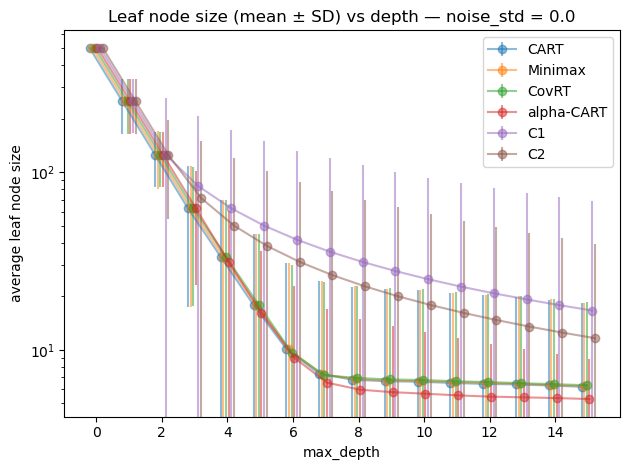

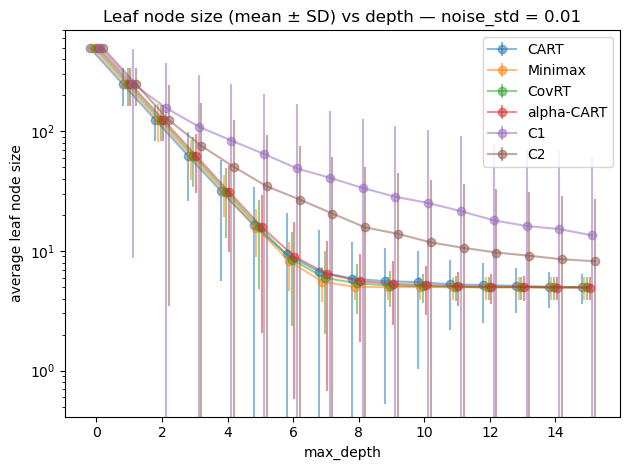

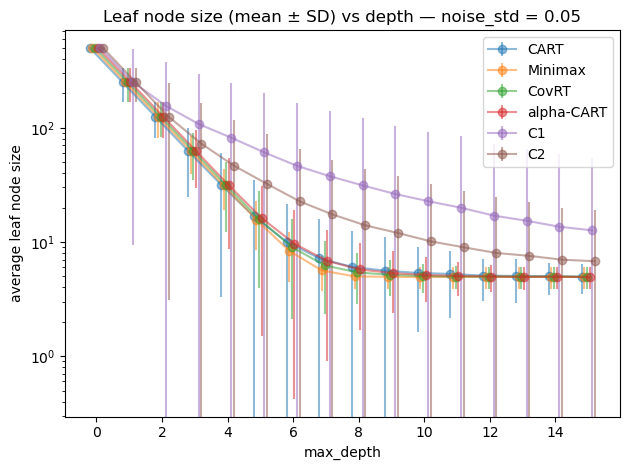

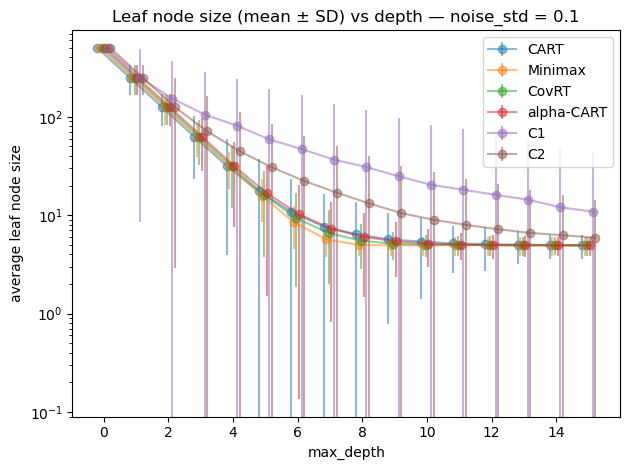

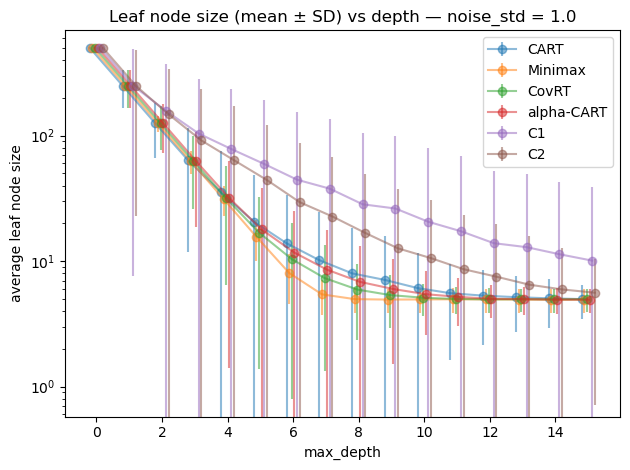

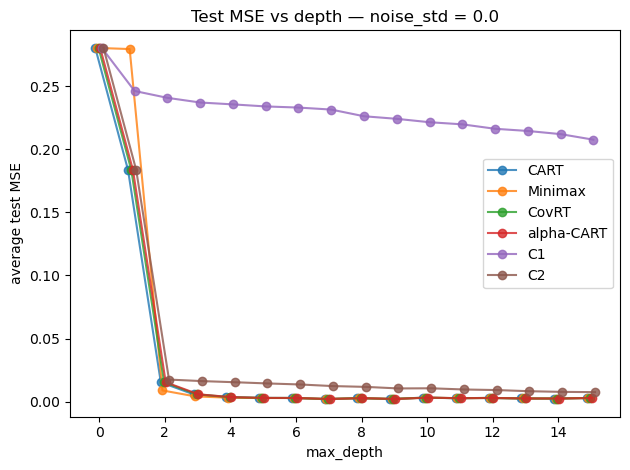

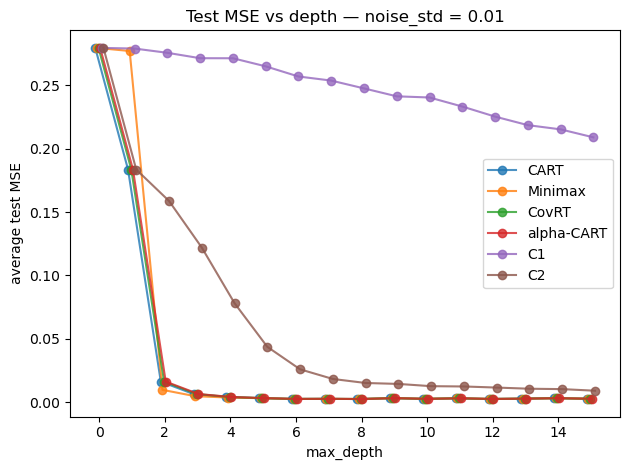

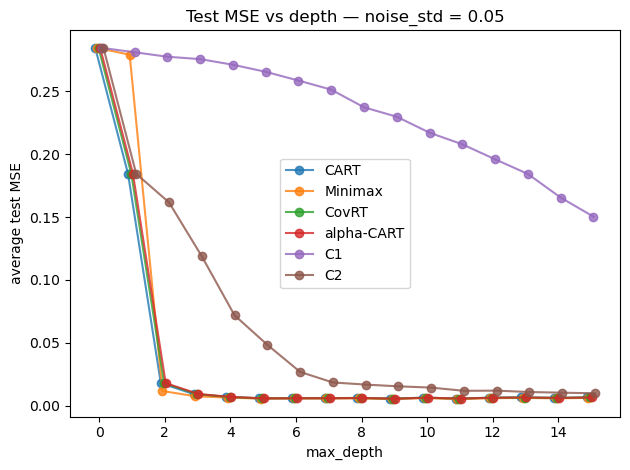

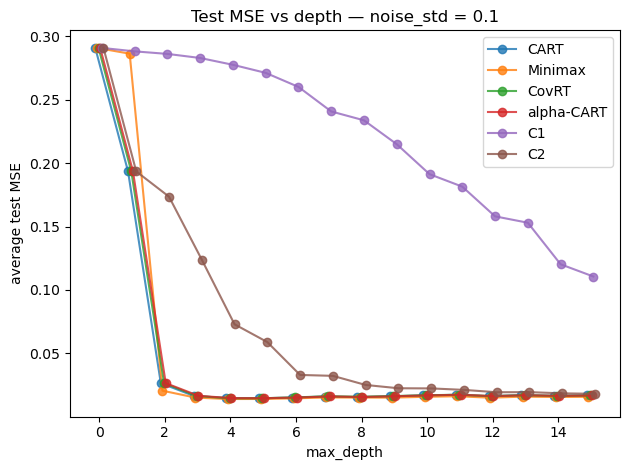

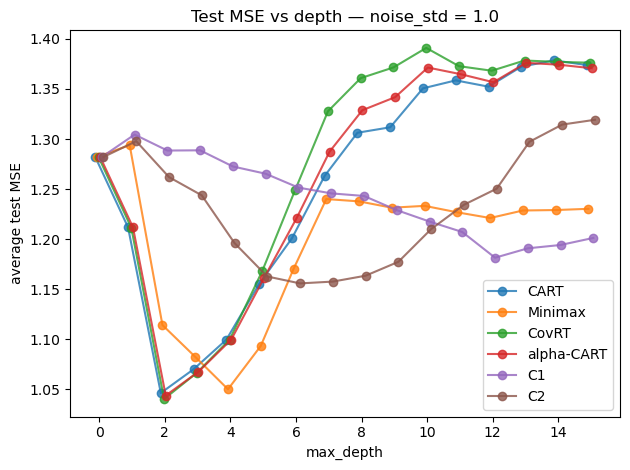

In [3]:
# ---------------------------------------------------------------------
# Simple 1D regression tree, keeping the original tree experiment style
# ---------------------------------------------------------------------
class TreeNode:
    __slots__ = ('is_leaf', 'pred', 'split_val', 'left', 'right', 'depth', 'indices')
    def __init__(self, indices, depth):
        self.is_leaf = True
        self.pred = None
        self.split_val = None
        self.left = None
        self.right = None
        self.depth = depth
        self.indices = indices

class SimpleTree:
    def __init__(self, criterion='cart', min_leaf=10, max_depth=6, alpha=None):
        self.criterion = criterion
        self.min_leaf = min_leaf
        self.max_depth = max_depth
        self.alpha = alpha
        self.root = None

    def fit(self, X, y):
        order = np.argsort(X)
        self.X_sorted = X[order]
        self.y_sorted = y[order]
        self.root = self._build(np.arange(len(y)), depth=0)

    def _build(self, indices, depth):
        node = TreeNode(indices, depth)
        y_node = self.y_sorted[indices]
        node.pred = y_node.mean()

        if depth >= self.max_depth:
            return node
        if len(indices) < 2 * self.min_leaf:
            return node

        split_idx_local, _, _ = best_split_sorted(
            self.y_sorted[indices],
            min_leaf=self.min_leaf,
            criterion=self.criterion,
            alpha=self.alpha
        )
        if split_idx_local is None:
            return node

        node.is_leaf = False
        split_global_idx = indices[split_idx_local]
        left_mask = indices < split_global_idx
        right_mask = ~left_mask
        left_indices = indices[left_mask]
        right_indices = indices[right_mask]

        if len(left_indices) == 0 or len(right_indices) == 0:
            node.is_leaf = True
            return node

        node.split_val = (self.X_sorted[split_global_idx - 1] + self.X_sorted[split_global_idx]) / 2.0
        node.left = self._build(left_indices, depth + 1)
        node.right = self._build(right_indices, depth + 1)
        return node

    def _predict_one(self, x, node):
        if node.is_leaf:
            return node.pred
        if x <= node.split_val:
            return self._predict_one(x, node.left)
        return self._predict_one(x, node.right)

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])

    def leaf_sizes(self):
        return self._collect_leaf_sizes(self.root)

    def _collect_leaf_sizes(self, node):
        if node.is_leaf:
            return [len(node.indices)]
        return self._collect_leaf_sizes(node.left) + self._collect_leaf_sizes(node.right)

    def depth(self):
        return self._max_depth(self.root)

    def _max_depth(self, node):
        if node.is_leaf:
            return node.depth
        return max(self._max_depth(node.left), self._max_depth(node.right))

def true_function(x):
    return np.where(x < 1/3, np.sin(x), np.where(x < 2/3, -2 * x, 0.0))

# quick summary at one setting
n_train = 500
n_test = 500
noise_std = 0.1
n_rep = 100
min_leaf = 4
max_depth = 12
alpha_tree = 0.10

criteria = {
    'CART': 'cart',
    'Minimax': 'minimax',
    'C1': 'C1',
    'C2': 'C2',
    'CovRT': 'covrt',
    'alpha-CART': 'alpha_cart',
}

results = {k: {'leaf_mean': [], 'leaf_var': [], 'depth': [], 'mse_train': [], 'mse_test': []} for k in criteria}

for rep in range(n_rep):
    X_train = rng.random(n_train)
    y_train = true_function(X_train) + rng.normal(0, noise_std, n_train)
    X_test = rng.random(n_test)
    y_test = true_function(X_test) + rng.normal(0, noise_std, n_test)

    for label, crit in criteria.items():
        tree = SimpleTree(criterion=crit, min_leaf=min_leaf, max_depth=max_depth,
                          alpha=(alpha_tree if crit == 'alpha_cart' else None))
        tree.fit(X_train, y_train)

        leaf_sizes = np.array(tree.leaf_sizes())
        yhat_train = tree.predict(X_train)
        yhat_test = tree.predict(X_test)

        results[label]['leaf_mean'].append(leaf_sizes.mean())
        results[label]['leaf_var'].append(leaf_sizes.var())
        results[label]['depth'].append(tree.depth())
        results[label]['mse_train'].append(np.mean((y_train - yhat_train) ** 2))
        results[label]['mse_test'].append(np.mean((y_test - yhat_test) ** 2))

summary = []
for label in criteria:
    res = results[label]
    summary.append({
        'Criterion': label,
        'Avg leaf size mean': np.mean(res['leaf_mean']),
        'Avg leaf size variance': np.mean(res['leaf_var']),
        'Avg depth': np.mean(res['depth']),
        'Avg train MSE': np.mean(res['mse_train']),
        'Avg test MSE': np.mean(res['mse_test']),
    })

df_summary = pd.DataFrame(summary)
print(df_summary.round(3))

# expanded grid, still plotted with the original simple error-bar style
n_train = 500
n_test = 500
noise_grid = [0.0, 0.01, 0.05, 0.1, 1.0]
depth_grid = list(range(0, 16))
n_rep = 100
min_leaf = 4

records = []

for noise_std in noise_grid:
    for max_depth in depth_grid:
        print("running:", noise_std, max_depth)
        for rep in range(n_rep):
            X_train = rng.random(n_train)
            y_train = true_function(X_train) + rng.normal(0, noise_std, n_train)
            X_test = rng.random(n_test)
            y_test = true_function(X_test) + rng.normal(0, noise_std, n_test)

            for label, crit in criteria.items():
                tree = SimpleTree(criterion=crit, min_leaf=min_leaf, max_depth=max_depth,
                                  alpha=(alpha_tree if crit == 'alpha_cart' else None))
                tree.fit(X_train, y_train)

                leaf_sizes = np.array(tree.leaf_sizes())
                yhat_train = tree.predict(X_train)
                yhat_test = tree.predict(X_test)

                records.append({
                    'criterion': label,
                    'noise_std': noise_std,
                    'max_depth': max_depth,
                    'leaf_mean': leaf_sizes.mean(),
                    'leaf_var': leaf_sizes.var(),
                    'tree_depth': tree.depth(),
                    'mse_train': np.mean((y_train - yhat_train) ** 2),
                    'mse_test': np.mean((y_test - yhat_test) ** 2),
                })

df_grid = pd.DataFrame.from_records(records)

summary_grid = (
    df_grid.groupby(['criterion', 'noise_std', 'max_depth'], as_index=False)
           .agg({'leaf_mean': 'mean',
                 'leaf_var': 'mean',
                 'tree_depth': 'mean',
                 'mse_train': 'mean',
                 'mse_test': 'mean'})
)

methods_plot = ['CART', 'Minimax', 'CovRT', 'alpha-CART', 'C1', 'C2']

for noise in noise_grid:
    fig = plt.figure()
    ax = fig.add_subplot(111)
    offset_idx = 0
    for method in methods_plot:
        sub = summary_grid[(summary_grid['noise_std'] == noise) & (summary_grid['criterion'] == method)]
        ax.errorbar(
            sub['max_depth'] + (offset_idx - (len(methods_plot) - 1) / 2) * 0.08,
            sub['leaf_mean'],
            yerr=np.sqrt(sub['leaf_var']),
            label=method,
            marker='o',
            linestyle='-',
            alpha=0.5
        )
        offset_idx += 1
    ax.set_xlabel("max_depth")
    ax.set_ylabel("average leaf node size")
    ax.set_yscale("log")
    ax.set_title(f"Leaf node size (mean ± SD) vs depth — noise_std = {noise}")
    ax.legend()
    plt.tight_layout()
    plt.show()

for noise in noise_grid:
    fig = plt.figure()
    ax = fig.add_subplot(111)
    offset_idx = 0
    for method in methods_plot:
        sub = summary_grid[(summary_grid['noise_std'] == noise) & (summary_grid['criterion'] == method)]
        ax.plot(
            sub['max_depth'] + (offset_idx - (len(methods_plot) - 1) / 2) * 0.05,
            sub['mse_test'],
            marker='o',
            linestyle='-',
            alpha=0.8,
            label=method
        )
        offset_idx += 1
    ax.set_xlabel("max_depth")
    ax.set_ylabel("average test MSE")
    ax.set_title(f"Test MSE vs depth — noise_std = {noise}")
    ax.legend()
    plt.tight_layout()
    plt.show()

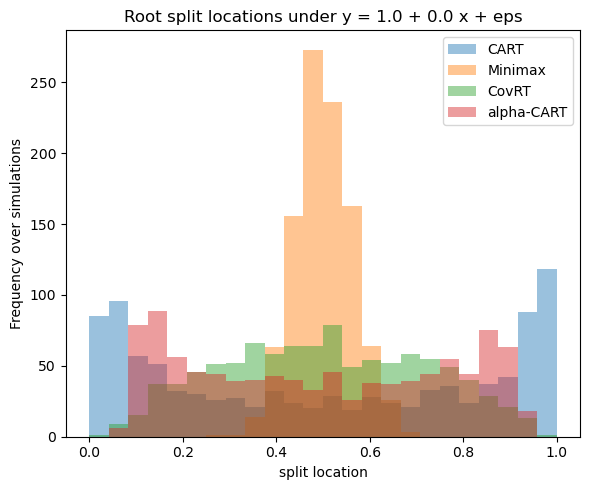

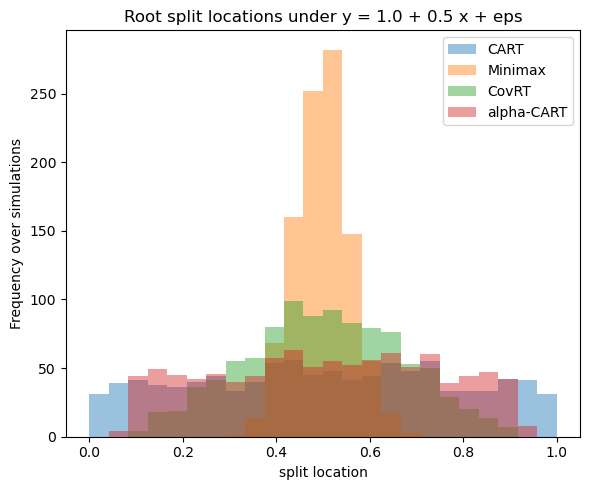

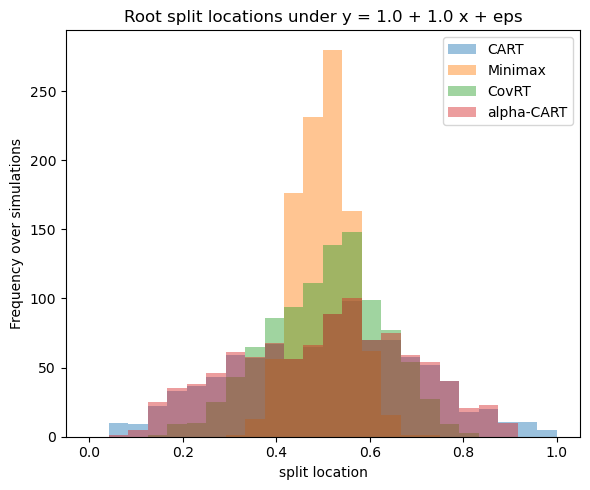

       Method  P(select true signal at root)
0        CART                          0.992
1     Minimax                          0.982
2       CovRT                          0.995
3  alpha-CART                          0.993


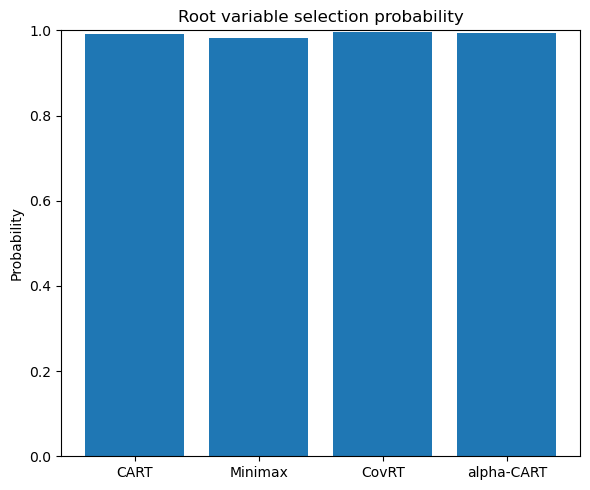

In [4]:
# ---------------------------------------------------------------------
# CovRT-style direct comparison, still using simple inline plots
# ---------------------------------------------------------------------
def root_split_index(y_sorted, criterion, min_leaf=4, alpha=None):
    idx, score, prop = best_split_sorted(y_sorted, min_leaf=min_leaf, criterion=criterion, alpha=alpha)
    return idx, score, prop

# split-point density under y = c0 + c1 x + eps
n = 200
reps = 1000
c0 = 1.0
c1_grid = [0.0, 0.5, 1.0]
sigma = 1.0
min_leaf = 4

for c1 in c1_grid:
    split_locations = {'CART': [], 'Minimax': [], 'CovRT': [], 'alpha-CART': []}

    for rep in range(reps):
        x = rng.random(n)
        y = c0 + c1 * x + rng.normal(scale=sigma, size=n)
        order = np.argsort(x)
        x_sorted = x[order]
        y_sorted = y[order]

        for method, crit in [('CART', 'cart'), ('Minimax', 'minimax'), ('CovRT', 'covrt'), ('alpha-CART', 'alpha_cart')]:
            idx, _, _ = best_split_sorted(y_sorted, min_leaf=min_leaf, criterion=crit,
                                          alpha=(0.10 if crit == 'alpha_cart' else None))
            if idx is not None and idx < len(x_sorted):
                split_locations[method].append(x_sorted[idx])

    plt.figure(figsize=(6, 5))
    bins = np.linspace(0, 1, 25)
    for method, vals in split_locations.items():
        plt.hist(vals, bins=bins, alpha=0.45, label=method, density=False)
    plt.title(f"Root split locations under y = {c0} + {c1} x + eps")
    plt.xlabel("split location")
    plt.ylabel("Frequency over simulations")
    plt.legend()
    plt.tight_layout()
    plt.show()

# signal-variable selection with one signal and four noise variables
n = 300
reps = 1000
min_leaf = 4
sigma = 1.0

selection = {'CART': [], 'Minimax': [], 'CovRT': [], 'alpha-CART': []}
for rep in range(reps):
    X = rng.random((n, 5))
    y = 1.0 + X[:, 0] + rng.normal(scale=sigma, size=n)

    for method, crit in [('CART', 'cart'), ('Minimax', 'minimax'), ('CovRT', 'covrt'), ('alpha-CART', 'alpha_cart')]:
        best_feature = None
        if crit in ('C2', 'covrt'):
            best_score = -inf
        else:
            best_score = inf

        for j in range(X.shape[1]):
            order = np.argsort(X[:, j])
            y_sorted = y[order]
            idx, score, _ = best_split_sorted(y_sorted, min_leaf=min_leaf, criterion=crit,
                                              alpha=(0.10 if crit == 'alpha_cart' else None))
            if idx is None:
                continue

            if crit in ('C2', 'covrt'):
                better = score > best_score
            else:
                better = score < best_score

            if better:
                best_score = score
                best_feature = j

        selection[method].append(best_feature == 0)

selection_summary = pd.DataFrame({
    'Method': list(selection.keys()),
    'P(select true signal at root)': [np.mean(selection[m]) for m in selection]
})
print(selection_summary.round(3))

plt.figure(figsize=(6, 5))
plt.bar(selection_summary['Method'], selection_summary['P(select true signal at root)'])
plt.ylim(0, 1)
plt.ylabel("Probability")
plt.title("Root variable selection probability")
plt.tight_layout()
plt.show()